### Import Libraries

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

### Paths

In [2]:
TEST_DIR = Path("../processed/test")

MODEL_PATH = "../models/best_model.keras"

### Load Model

In [3]:
model = tf.keras.models.load_model(
    MODEL_PATH
)

print("Model Loaded Successfully")

Model Loaded Successfully


### Load Test Dataset

In [4]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

In [5]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 805 files belonging to 6 classes.


### Class Names

In [6]:
class_names = test_ds.class_names

print(class_names)

['bacterial_leaf_blight', 'blast', 'brown_spot', 'healthy', 'leaf_scald', 'sheath_blight']


### Generate Predictions

#### True Labels

In [8]:
y_true = np.concatenate(
    [y.numpy() for x, y in test_ds]
)

#### Predicted Probabilities

In [9]:
y_pred_probs = model.predict(
    test_ds
)

26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 261ms/step


#### Predicted Labels

In [10]:
y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

### Overall Accuracy

In [11]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    f"Test Accuracy: {accuracy:.4f}"
)

Test Accuracy: 0.7863


### Classification Report

In [12]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

                       precision    recall  f1-score   support

bacterial_leaf_blight       0.79      0.72      0.75       130
                blast       0.69      0.81      0.74       149
           brown_spot       0.92      0.59      0.72       145
              healthy       0.82      0.99      0.90       122
           leaf_scald       0.71      0.78      0.74       123
        sheath_blight       0.86      0.85      0.86       136

             accuracy                           0.79       805
            macro avg       0.80      0.79      0.79       805
         weighted avg       0.80      0.79      0.78       805



### Classification Report DataFrame

In [13]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(
    report_dict
).transpose()

report_df

,precision,recall,f1-score,support
bacterial_leaf_blight,0.794872,0.715385,0.753036,130.000000
blast,0.687500,0.812081,0.744615,149.000000
brown_spot,0.924731,0.593103,0.722689,145.000000
healthy,0.817568,0.991803,0.896296,122.000000
leaf_scald,0.705882,0.780488,0.741313,123.000000
sheath_blight,0.859259,0.852941,0.856089,136.000000
accuracy,0.786335,0.786335,0.786335,0.786335
macro avg,0.798302,0.790967,0.785673,805.000000
weighted avg,0.799109,0.786335,0.783342,805.000000


### Confusion Matrix

In [14]:
cm = confusion_matrix(
    y_true,
    y_pred
)

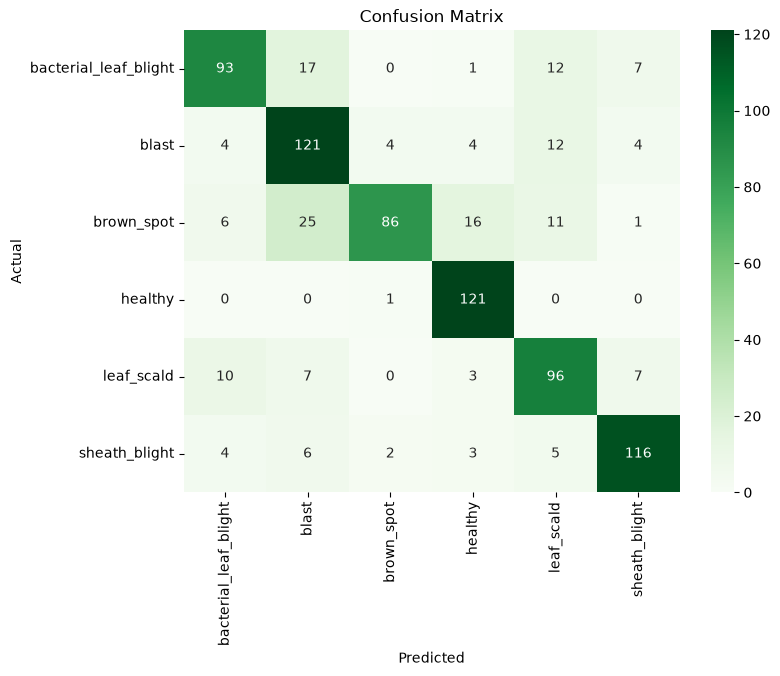

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

### Visualize Misclassified Images

#### Get Images

In [16]:
images = np.concatenate(
    [x.numpy() for x, y in test_ds]
)

images.shape

(805, 224, 224, 3)

#### Find Errors

In [17]:
misclassified = np.where(
    y_true != y_pred
)[0]

print(
    f"Misclassified Images: {len(misclassified)}"
)

Misclassified Images: 172


#### Display First 9 Errors

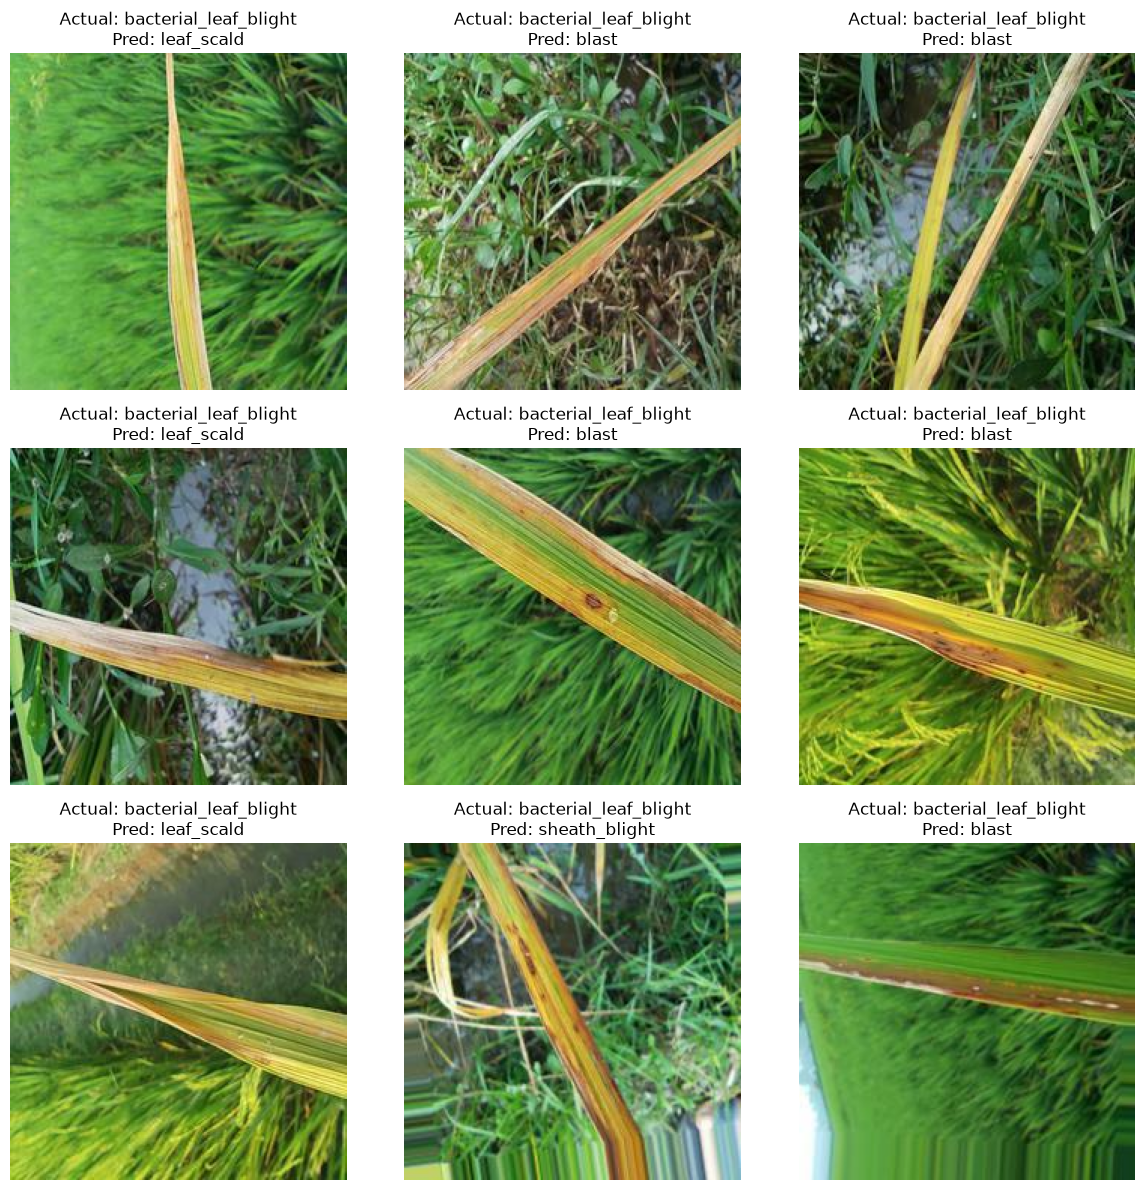

In [18]:
plt.figure(figsize=(12,12))

for i, idx in enumerate(
    misclassified[:9]
):

    plt.subplot(3,3,i+1)

    plt.imshow(
        images[idx].astype("uint8")
    )

    plt.title(
        f"Actual: {class_names[y_true[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

### Class-wise Accuracy

In [19]:
class_accuracy = {}

for i, class_name in enumerate(class_names):

    indices = np.where(
        y_true == i
    )[0]

    correct = np.sum(
        y_pred[indices] == i
    )

    accuracy = correct / len(indices)

    class_accuracy[class_name] = accuracy

In [20]:
class_acc_df = pd.DataFrame(
    class_accuracy.items(),
    columns=["Class","Accuracy"]
)

class_acc_df

,Class,Accuracy
0,bacterial_leaf_blight,0.715385
1,blast,0.812081
2,brown_spot,0.593103
3,healthy,0.991803
4,leaf_scald,0.780488
5,sheath_blight,0.852941


### Plot Class Accuracy

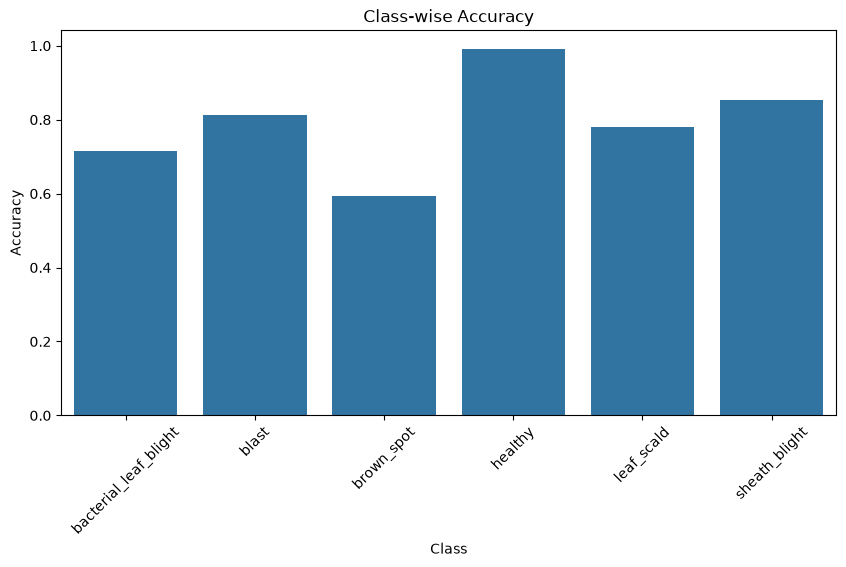

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=class_acc_df,
    x="Class",
    y="Accuracy"
)

plt.xticks(rotation=45)

plt.title(
    "Class-wise Accuracy"
)

plt.show()

### Save Evaluation Report

In [22]:
report_df.to_csv(
    "../models/classification_report.csv"
)

print(
    "Evaluation report saved."
)

Evaluation report saved.
